In [189]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as VF
from PIL import Image
import time
import numpy as np

device = 'cuda'
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
train_dataset = datasets.MNIST(
    root="./DATA",
    train=True,
    download=True,
    transform=transform)

test_dataset = datasets.MNIST(
    root="./DATA",
    train=False,
    download=True,
    transform=transform)    

100.0%
100.0%
100.0%
100.0%


In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 1024)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        return x

In [5]:
def test_model(model, dataloader, criterion):
    model.eval()
    running_loss_test = 0.0
    n_obs_test = 0
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        running_loss_test += loss.item() * len(data)
        n_obs_test += len(data)
    epoch_loss_test = running_loss_test / n_obs_test
    return epoch_loss_test

In [249]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False)

In [345]:
train_loader3 = DataLoader(
    dataset=train_dataset,
    batch_size=18192,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
    drop_last=True)
model.zero_grad()
data_iter = iter(train_loader3)
data, label = next(data_iter)
data, label = data.to(device), label.to(device)
output = model(data)
loss = criterion(output, label)
loss.backward()
grad_vector_ref = torch.cat([p.grad.detach().flatten() for p in model.parameters()])
print(grad_vector_ref.mean()*1e8)

tensor(-12.9955, device='cuda:0')


In [305]:
model.eval()
n_repeat = 25
for n in [16]:
    for k in [128]:
        S = []
        for j in range(n_repeat):
            train_loader2 = DataLoader(
                dataset=train_dataset,
                batch_size=k,
                shuffle=True,
                num_workers=0,
                pin_memory=False,
                persistent_workers=False,
                drop_last=True)
            
            grads = []
            data_iter = iter(train_loader2)
            for i in range(n):
                model.zero_grad()
                data, label = next(data_iter)
                data, label = data.to(device), label.to(device)
                output = model(data)
                loss = criterion(output, label)
                loss.backward()
                grad_vector = torch.cat([p.grad.detach().flatten() for p in model.parameters()])
                grads.append(grad_vector)
            G = torch.stack(grads)
            
            grad_var = torch.var(G, dim=0)
            grad_mean = torch.mean(G, dim=0)
            S.append((grad_var.mean() / grad_vector_ref.pow(2).mean()).item())
        print(f"n={n} k={k} Mean S={np.array(S).mean():.2f} StdDev S={np.array(S).std():.2f} Volatility S={np.array(S).std()/np.array(S).mean():.3f} Batch size={k*np.array(S).mean():.0f}")
            #print(f"k={k} n={n} S={S/n_repeat:.4f} Grad var={grad_var.mean():.9f} Grad mean^2={grad_vector_ref.pow(2).mean():.9f}")

n=16 k=128 Mean S=2.88 StdDev S=1.61 Volatility S=0.559 Batch size=369


In [256]:
model = SimpleNN().to(device)

In [294]:
model = SimpleNN().to(device)
optimizer = optim.Adam(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)
criterion = nn.CrossEntropyLoss()

exp_folder = f'runs/model_{int(time.time())}'
writer_train = SummaryWriter(f"{exp_folder}/train")
writer_valid = SummaryWriter(f"{exp_folder}/valid")
global_step = 0
beta1, beta2 = optimizer.param_groups[0]["betas"]
base_lr = optimizer.param_groups[0]["lr"]
eps = optimizer.param_groups[0]["eps"]
for epoch in range(50):
    running_loss = 0.0
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        running_loss += loss.item()

        # Log Params Batch
        total_param_norm = 0.0
        total_param_count = 0.0
        total_grad_norm = 0.0
        for name, param in model.named_parameters():
            if param.requires_grad:
                if "bias" in name:
                    short_name = name[:-5]
                    group_name = "Bias"
                else:
                    short_name = name[:-7]
                    group_name = "Weight"
                
                writer_train.add_scalar(f"{group_name}_param_norm_scaled/{short_name}", param.data.norm(2) / (param.data.numel() ** 0.5), global_step) 
                writer_train.add_scalar(f"{group_name}_gradient_norm/{short_name}", param.grad.data.norm(2), global_step) 

                total_param_norm += param.data.norm(2) ** 2
                total_param_count += param.data.numel()
                total_grad_norm += param.grad.data.norm(2) ** 2

                if global_step>0:
                    step = optimizer.state[param]['step'] 
                    m_t = optimizer.state[param]['exp_avg'] / (1 - beta1 ** step)
                    v_t = optimizer.state[param]['exp_avg_sq'] / (1 - beta2 ** step)
                    effective_update = base_lr * m_t / (v_t ** 0.5 + eps)
                    writer_train.add_scalar(f"{group_name}_update_ratio/{short_name}", effective_update.abs().mean() / param.detach().abs().mean(), global_step)
        
        writer_train.add_scalar(f"Total_norm/Param_scaled", (total_param_norm / total_param_count) ** 0.5, global_step) 
        writer_train.add_scalar(f"Total_norm/Gradient", total_grad_norm ** 0.5, global_step)
        writer_train.add_scalar("Loss/batch", loss.item(), global_step)
        
        global_step += 1
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() 

    # Log Params Epoch
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "bias" in name:
                short_name = name[:-5]
                group_name = "Bias"
            else:
                short_name = name[:-7]
                group_name = "Weight"
        writer_train.add_histogram(f"{group_name}_param/{short_name}", param.data.cpu(), epoch)
        writer_train.add_histogram(f"{group_name}_gradient/{short_name}", param.grad.data.cpu(), epoch)
    loss_train_epoch = running_loss / len(train_loader)
    writer_train.add_scalar("Loss_epoch", loss_train_epoch, epoch)

    loss_valid_epoch = test_model(model = model, dataloader = test_loader, criterion = criterion)
    writer_valid.add_scalar("Loss_epoch", loss_valid_epoch, epoch)        
writer_train.close()
writer_valid.close()

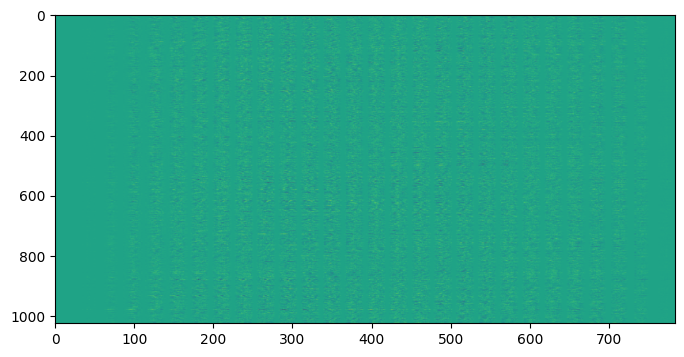

In [8]:
data = model.fc1.weight.detach().cpu().numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.imshow(data, cmap='viridis', aspect='auto')
plt.show()